<a href="https://colab.research.google.com/github/Shloka-16/deepfake-detection/blob/final_organization/notebooks/04_resnet50_evaluate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ResNet-50 Evaluation
Loads the checkpoint from `01_resnet50_train.ipynb`, selects the classification
threshold on validation data, then runs the one-time official test evaluation
and error analysis. Requires `models/best_resnet50.pth` to already exist.

## 1. Install packages

In [ ]:
!pip install -q kaggle kagglehub

## 2. Imports, labels, seed, and shared helpers

Shared settings and helper functions from the team's exploration notebook, copied so this notebook runs on its own. Real = 0, Fake = 1, and Fake is the positive class for precision, recall, and F1.

In [ ]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

SEED = 42

REAL_LABEL = 0
FAKE_LABEL = 1
CLASS_NAMES = ["Real", "Fake"]

VALID_SAMPLES_PER_CLASS = 1000
TEST_SAMPLES_PER_CLASS = 1000
NEURAL_NETWORK_BATCH_SIZE = 32


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


def create_seeded_data_loader(dataset, batch_size=NEURAL_NETWORK_BATCH_SIZE, shuffle=False, seed=SEED):
    generator = None
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(seed)
    return DataLoader(dataset=dataset, batch_size=batch_size, shuffle=shuffle, generator=generator, num_workers=0)


def make_balanced_sample(real_paths, fake_paths, samples_per_class, seed=SEED):
    if len(real_paths) < samples_per_class or len(fake_paths) < samples_per_class:
        raise ValueError("The requested sample is larger than one of the classes.")
    python_rng = random.Random(seed)
    selected_real_paths = python_rng.sample(list(real_paths), samples_per_class)
    selected_fake_paths = python_rng.sample(list(fake_paths), samples_per_class)
    selected_paths = selected_real_paths + selected_fake_paths
    selected_targets = np.array([REAL_LABEL] * samples_per_class + [FAKE_LABEL] * samples_per_class, dtype=np.int64)
    shuffle_order = np.random.default_rng(seed).permutation(len(selected_paths))
    shuffled_paths = [selected_paths[index] for index in shuffle_order]
    shuffled_targets = selected_targets[shuffle_order]
    return shuffled_paths, shuffled_targets


seed_everything()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed: {SEED}")
print(f"Label convention: Real = {REAL_LABEL}, Fake = {FAKE_LABEL}")
print(f"PyTorch device: {DEVICE}")

Seed: 42
Label convention: Real = 0, Fake = 1
PyTorch device: cuda


## 3. Download the dataset from Kaggle

Uses the **140k Real and Fake Faces** dataset. The token is read from Colab Secrets and only copied into the temporary runtime.

In [ ]:
from google.colab import userdata
import subprocess

DATASET_ROOT = Path("/content/real_vs_fake/real-vs-fake")


def download_kaggle_dataset(dataset_name="xhlulu/140k-real-and-fake-faces", download_directory=Path("/content")):
    """Download and unzip the Kaggle dataset into the Colab runtime."""
    if DATASET_ROOT.exists():
        print(f"Dataset already found at: {DATASET_ROOT}")
        return

    kaggle_token = userdata.get("KAGGLE_API_TOKEN")
    if not kaggle_token:
        raise ValueError("KAGGLE_API_TOKEN was not found in Colab Secrets.")

    kaggle_directory = Path.home() / ".kaggle"
    kaggle_directory.mkdir(parents=True, exist_ok=True)

    token_path = kaggle_directory / "access_token"
    token_path.write_text(kaggle_token)
    token_path.chmod(0o600)

    print(f"Downloading Kaggle dataset: {dataset_name}")
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", dataset_name, "--unzip", "-p", str(download_directory)],
        check=True,
    )
    print("Dataset download and extraction complete.")


download_kaggle_dataset()

Dataset download and extraction complete.


## 4. Locate the dataset images

Uses the official train and valid folders. The test folder stays untouched so it can be reserved for final evaluation later.

In [ ]:
VALID_REAL_DIRECTORY = DATASET_ROOT / "valid" / "real"
VALID_FAKE_DIRECTORY = DATASET_ROOT / "valid" / "fake"
TEST_REAL_DIRECTORY = DATASET_ROOT / "test" / "real"
TEST_FAKE_DIRECTORY = DATASET_ROOT / "test" / "fake"


def list_image_paths(directory):
    return sorted(path for path in directory.glob("*") if path.suffix.lower() in {".jpg", ".jpeg", ".png"})


valid_real_paths = list_image_paths(VALID_REAL_DIRECTORY)
valid_fake_paths = list_image_paths(VALID_FAKE_DIRECTORY)
test_real_paths = list_image_paths(TEST_REAL_DIRECTORY)
test_fake_paths = list_image_paths(TEST_FAKE_DIRECTORY)

display(pd.DataFrame([
    {"Split": "Valid", "Real": len(valid_real_paths), "Fake": len(valid_fake_paths)},
    {"Split": "Test", "Real": len(test_real_paths), "Fake": len(test_fake_paths)},
]))

,Split,Real,Fake
0,Train,50000,50000
1,Valid,10000,10000


## 5. Build the shared balanced sample

The same reproducible 5,000-per-class training sample and 1,000-per-class validation sample used across the team's experiments.

In [ ]:
project_valid_paths, project_valid_targets = make_balanced_sample(
    valid_real_paths, valid_fake_paths, samples_per_class=VALID_SAMPLES_PER_CLASS, seed=SEED,
)
project_test_paths, project_test_targets = make_balanced_sample(
    test_real_paths, test_fake_paths, samples_per_class=TEST_SAMPLES_PER_CLASS, seed=SEED,
)

display(pd.DataFrame([
    {"Split": "Validation", "Total": len(project_valid_paths),
     "Real": int((project_valid_targets == REAL_LABEL).sum()), "Fake": int((project_valid_targets == FAKE_LABEL).sum())},
    {"Split": "Test", "Total": len(project_test_paths),
     "Real": int((project_test_targets == REAL_LABEL).sum()), "Fake": int((project_test_targets == FAKE_LABEL).sum())},
]))

assert len(set(project_valid_paths).intersection(project_test_paths)) == 0
print("Validation and test paths do not overlap.")

,Split,Total images,Real,Fake
0,Training,10000,5000,5000
1,Validation,2000,1000,1000


Training and validation paths do not overlap.


## 6. ResNet-50 datasets

ResNet expects 224x224 images normalized with the ImageNet mean and standard deviation. The same shared paths are used, only the transform differs.

In [ ]:
class FacePathDataset(Dataset):
    def __init__(self, image_paths, numeric_targets, image_transform):
        if len(image_paths) != len(numeric_targets):
            raise ValueError("Image paths and targets must have equal length.")
        self.image_paths = list(image_paths)
        self.numeric_targets = np.asarray(numeric_targets, dtype=np.int64)
        self.image_transform = image_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        with Image.open(self.image_paths[index]) as image:
            rgb_image = image.convert("RGB")
        transformed_image = self.image_transform(rgb_image)
        numeric_target = torch.tensor(self.numeric_targets[index], dtype=torch.float32)
        return transformed_image, numeric_target


resnet50_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

resnet50_valid_dataset = FacePathDataset(project_valid_paths, project_valid_targets, resnet50_transform)
resnet50_test_dataset = FacePathDataset(project_test_paths, project_test_targets, resnet50_transform)

resnet50_valid_loader = create_seeded_data_loader(resnet50_valid_dataset, shuffle=False)
resnet50_test_loader = create_seeded_data_loader(resnet50_test_dataset, shuffle=False)

print(f"ResNet-50 validation images: {len(resnet50_valid_dataset)}")
print(f"ResNet-50 test images: {len(resnet50_test_dataset)}")

ResNet-50 training images: 10000
ResNet-50 validation images: 2000


## 7. Model Builder

`build_resnet50_transfer_model` creates a fresh frozen-backbone model with a new binary head every run, which is what makes training repeatable.


In [ ]:
def build_resnet50_transfer_model(device):
    seed_everything()
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    for parameter in model.parameters():
        parameter.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.40),
        nn.Linear(256, 1),
    )
    return model.to(device)

## 8. Load the trained checkpoint

Monitoring Fake F1 balances catching fakes against false accusations. Switch `monitor_metric` to `"Fake recall"` if the team decides missing a fake is worse than a false alarm.

**Note:** `best_resnet50.pth` saves to the temporary Colab runtime. Download it (or mount Google Drive and point `checkpoint_path` there) so it survives a disconnect.

In [ ]:
resnet50_transfer_model = build_resnet50_transfer_model(DEVICE)

checkpoint = torch.load("models/best_resnet50.pth", map_location=DEVICE)
resnet50_transfer_model.load_state_dict(checkpoint["model_state_dict"])
resnet50_transfer_model.eval()

print("Loaded best ResNet-50 checkpoint")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


Epoch 01/10  train loss 0.4412  val loss 0.3547  acc 0.8490  Fake F1 0.8442
  saved new best checkpoint (Fake F1 = 0.8442)
Epoch 02/10  train loss 0.3017  val loss 0.3057  acc 0.8740  Fake F1 0.8708
  saved new best checkpoint (Fake F1 = 0.8708)
Epoch 03/10  train loss 0.2563  val loss 0.2793  acc 0.8830  Fake F1 0.8842
  saved new best checkpoint (Fake F1 = 0.8842)
Epoch 04/10  train loss 0.2232  val loss 0.2655  acc 0.8940  Fake F1 0.8947
  saved new best checkpoint (Fake F1 = 0.8947)
Epoch 05/10  train loss 0.2012  val loss 0.2629  acc 0.8905  Fake F1 0.8907
Epoch 06/10  train loss 0.1848  val loss 0.2576  acc 0.8950  Fake F1 0.8968
  saved new best checkpoint (Fake F1 = 0.8968)
Epoch 07/10  train loss 0.1705  val loss 0.2614  acc 0.8925  Fake F1 0.8909
Epoch 08/10  train loss 0.1575  val loss 0.2798  acc 0.8910  Fake F1 0.8865
Epoch 09/10  train loss 0.1356  val loss 0.2575  acc 0.8985  Fake F1 0.8987
  saved new best checkpoint (Fake F1 = 0.8987)
Epoch 10/10  train loss 0.1253  va

,Epoch,Train loss,Val loss,Accuracy,Fake precision,Fake recall,Fake F1
0,1,0.4412,0.3547,0.8490,0.8721,0.818,0.8442
1,2,0.3017,0.3057,0.8740,0.8937,0.849,0.8708
2,3,0.2563,0.2793,0.8830,0.8755,0.893,0.8842
3,4,0.2232,0.2655,0.8940,0.8886,0.901,0.8947
4,5,0.2012,0.2629,0.8905,0.8893,0.892,0.8907
5,6,0.1848,0.2576,0.8950,0.8820,0.912,0.8968
6,7,0.1705,0.2614,0.8925,0.9042,0.878,0.8909
7,8,0.1575,0.2798,0.8910,0.9250,0.851,0.8865
8,9,0.1356,0.2575,0.8985,0.8973,0.900,0.8987
9,10,0.1253,0.2922,0.8910,0.8510,0.948,0.8969


## 9. Evaluate Model

In [ ]:
def evaluate_model(model, loader, device, threshold=0.50):

    model.eval()

    targets = []
    probabilities = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            logits = model(images)

            probs = torch.sigmoid(logits).view(-1)

            targets.extend(labels.numpy().astype(int))
            probabilities.extend(probs.cpu().numpy())

    probabilities = np.array(probabilities)
    targets = np.array(targets)

    predictions = (probabilities >= threshold).astype(int)

    return {
        "targets": targets,
        "probabilities": probabilities,
        "predictions": predictions,
    }

Run on Validation

In [ ]:
validation_results = evaluate_model(resnet50_transfer_model, resnet50_valid_loader, DEVICE)

In [ ]:
threshold_results = []

for threshold in np.arange(0.10,0.91,0.05):

    predictions = (
        validation_results["probabilities"] >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy":
            accuracy_score(
                validation_results["targets"],
                predictions
            ),

        "Precision":
            precision_score(
                validation_results["targets"],
                predictions,
                pos_label=FAKE_LABEL,
                zero_division=0
            ),

        "Recall":
            recall_score(
                validation_results["targets"],
                predictions,
                pos_label=FAKE_LABEL,
                zero_division=0
            ),

        "F1":
            f1_score(
                validation_results["targets"],
                predictions,
                pos_label=FAKE_LABEL,
                zero_division=0
            )

    })

threshold_table = pd.DataFrame(threshold_results)

display(threshold_table)
threshold_table.to_csv("results/resnet50_threshold_sweep.csv", index=False)


,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.8560,0.783892,0.983,0.872227
1,0.15,0.8705,0.806959,0.974,0.882646
2,0.20,0.8840,0.832180,0.962,0.892393
3,0.25,0.8895,0.846222,0.952,0.896000
4,0.30,0.8940,0.858834,0.943,0.898951
5,0.35,0.8970,0.867593,0.937,0.900962
6,0.40,0.8990,0.875706,0.930,0.902037
7,0.45,0.9015,0.887923,0.919,0.903194
8,0.50,0.8985,0.897308,0.900,0.898652
9,0.55,0.8995,0.905584,0.892,0.898741


In [ ]:
# Pick Threshold
best_row = threshold_table.loc[threshold_table["F1"].idxmax()]
display(best_row)
best_threshold = float(best_row["Threshold"])
print(f"Selected threshold: {best_threshold:.2f}")

In [ ]:
best_threshold = threshold_table.loc[
    threshold_table["F1"].idxmax(),
    "Threshold"
]

best_row = threshold_table.loc[
    threshold_table["F1"].idxmax()
]

display(best_row)

best_threshold = float(best_row["Threshold"])

print(f"Selected threshold: {best_threshold:.2f}")

,7
Threshold,0.450000
Accuracy,0.901500
Precision,0.887923
Recall,0.919000
F1,0.903194


Selected threshold: 0.45


We optimize the classification threshold for balanced F1 rather than pure recall
or pure precision. In this deepfake-detection setting, both error types carry
real cost: missing a fake (false negative) lets synthetic content through
undetected, while falsely flagging a real photo as fake (false positive) is a
reputational/trust cost for the person wrongly accused. Since neither error is
categorically worse for this project's use case, F1 gives the best single-number
tradeoff. The 0.05-step sweep from 0.10-0.90 shows F1 peaks at threshold 0.45
(Precision 0.888, Recall 0.919), which is what we freeze before touching the test set.

In [ ]:
test_results = evaluate_model(
    resnet50_transfer_model,
    resnet50_test_loader,
    DEVICE,
    threshold=best_threshold
)

In [ ]:
# test metrics table
test_accuracy = accuracy_score(
    test_results["targets"],
    test_results["predictions"]
)

test_precision = precision_score(
    test_results["targets"],
    test_results["predictions"],
    pos_label=FAKE_LABEL,
    zero_division=0
)

test_recall = recall_score(
    test_results["targets"],
    test_results["predictions"],
    pos_label=FAKE_LABEL,
    zero_division=0
)

test_f1 = f1_score(
    test_results["targets"],
    test_results["predictions"],
    pos_label=FAKE_LABEL,
    zero_division=0
)

test_metrics = pd.DataFrame([{
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1
}])

display(test_metrics.round(4))

,Accuracy,Precision,Recall,F1
0,0.911,0.8998,0.925,0.9122


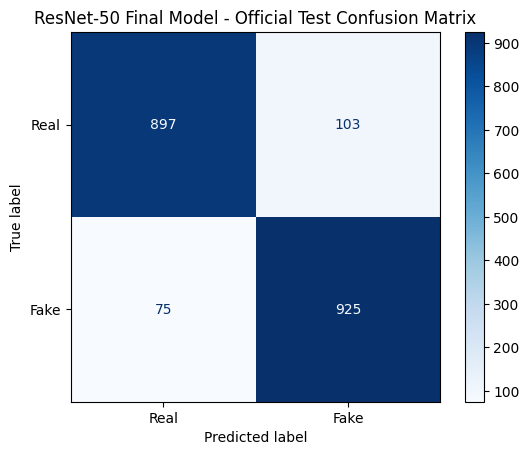

,Class,Actual count,Predicted count
0,Real,1000,972
1,Fake,1000,1028


Saved: resnet50_test_results.csv, resnet50_test_class_counts.csv, resnet50_test_confusion_matrix.png


In [ ]:
# ---- Test set confusion matrix ----
ConfusionMatrixDisplay.from_predictions(
    test_results["targets"],
    test_results["predictions"],
    display_labels=CLASS_NAMES,
    cmap="Blues",
)
plt.title("ResNet-50 Final Model - Official Test Confusion Matrix")
plt.savefig("resnet50_test_confusion_matrix.png", bbox_inches="tight")
plt.show()

# ---- Class counts (actual vs predicted) ----
test_class_counts = pd.DataFrame(
    [
        {
            "Class": "Real",
            "Actual count": int((test_results["targets"] == REAL_LABEL).sum()),
            "Predicted count": int((test_results["predictions"] == REAL_LABEL).sum()),
        },
        {
            "Class": "Fake",
            "Actual count": int((test_results["targets"] == FAKE_LABEL).sum()),
            "Predicted count": int((test_results["predictions"] == FAKE_LABEL).sum()),
        },
    ]
)
display(test_class_counts)

# ---- Save everything so it's not lost if the runtime disconnects ----
test_metrics_with_meta = test_metrics.copy()
test_metrics_with_meta["Threshold used"] = best_threshold
test_metrics_with_meta["Checkpoint"] = "best_resnet50.pth"
test_metrics_with_meta["Test images"] = len(test_results["targets"])

test_metrics_with_meta.to_csv("resnet50_test_results.csv", index=False)
test_class_counts.to_csv("resnet50_test_class_counts.csv", index=False)

print("Saved: resnet50_test_results.csv, resnet50_test_class_counts.csv, resnet50_test_confusion_matrix.png")

False positives (Real called Fake): 103
False negatives (Fake called Real): 75


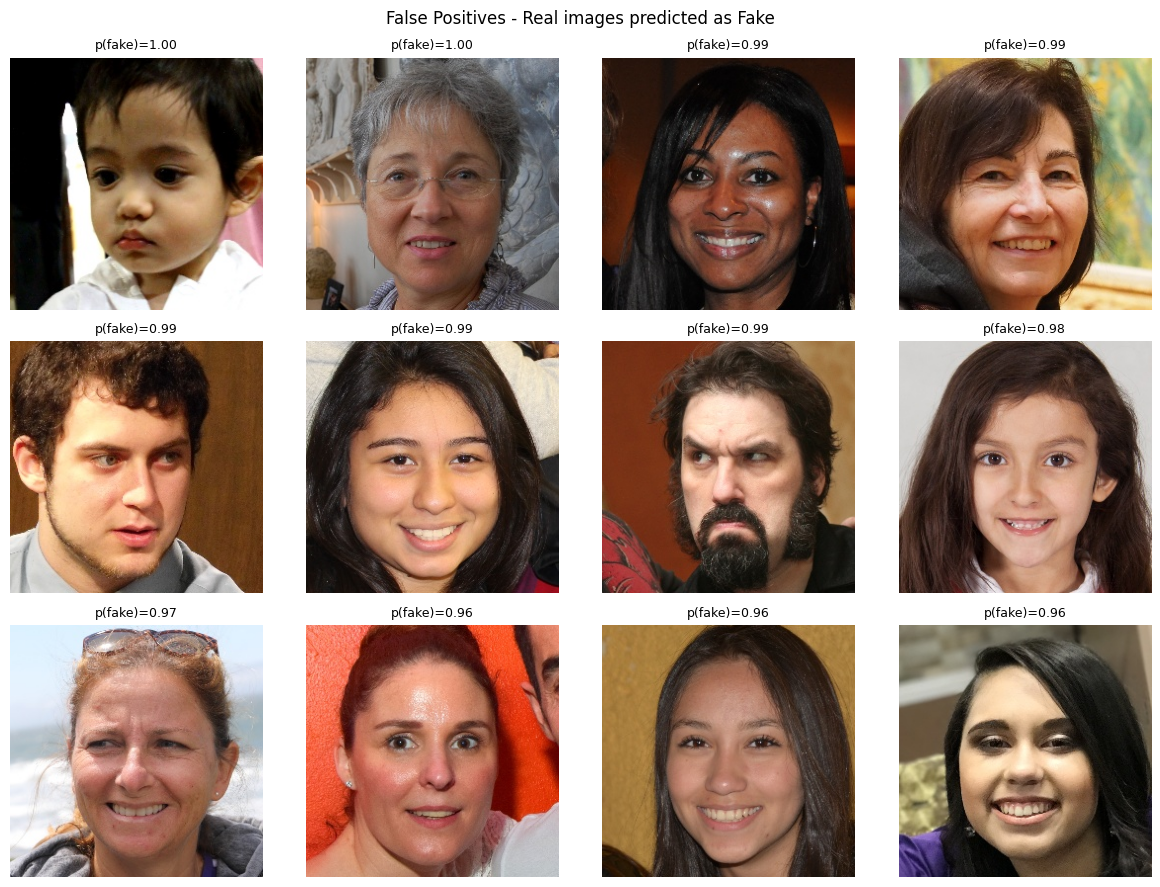

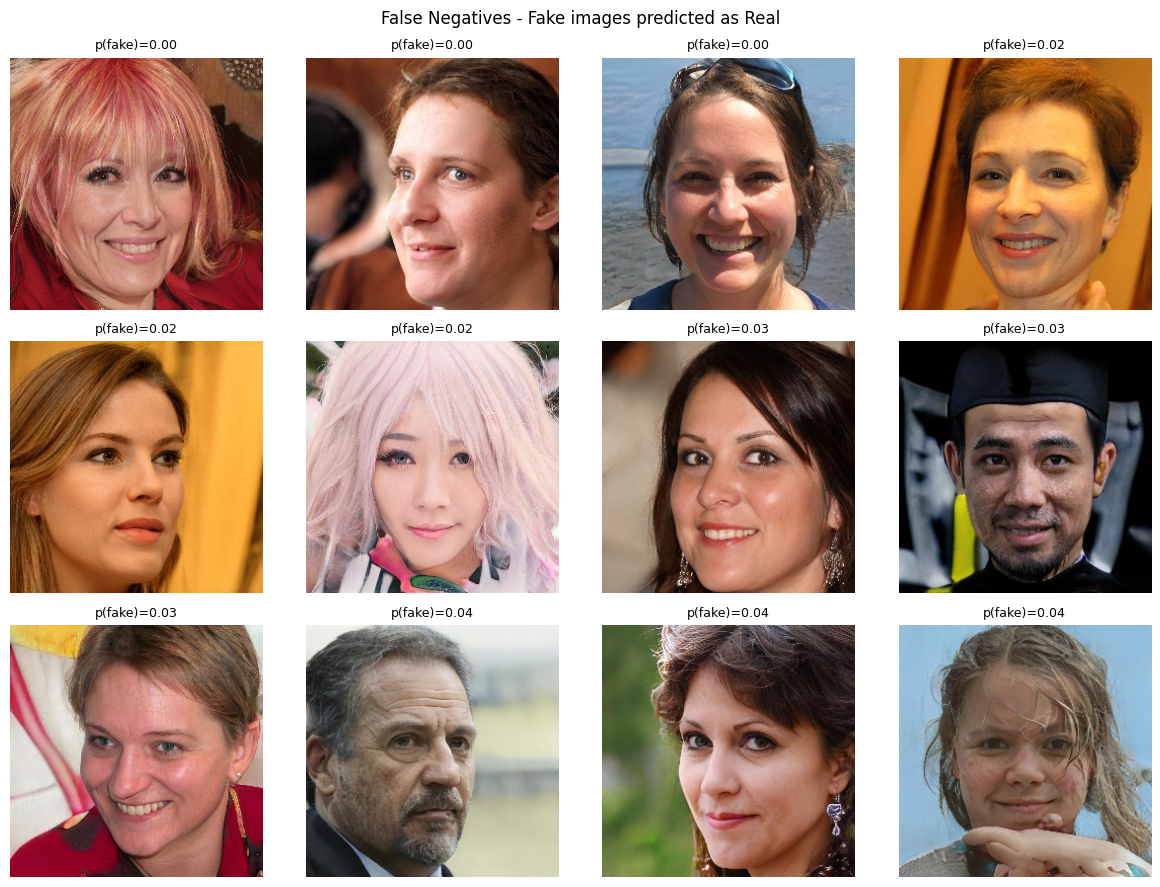

,Error type,Example count shown
0,False positive (Real -> Fake),12
1,False negative (Fake -> Real),12


Saved: resnet50_error_analysis.csv

Limitations: error analysis is based only on the 2,000-image test sample (1,000 Real / 1,000 Fake) and the 12 most-confident mistakes per error type, so it may not capture rarer failure modes. No retraining or threshold changes were made based on these observations.


In [ ]:
# ---- Error analysis ----
# Identify false positives (Real predicted as Fake) and false negatives
# (Fake predicted as Real) on the test set, and inspect a sample of each
# to look for patterns. We only look at test-set mistakes for reporting
# purposes; we do NOT retrain or tune anything based on what we see here.

test_predictions_df = pd.DataFrame(
    {
        "path": project_test_paths,
        "true_label": test_results["targets"],
        "predicted_label": test_results["predictions"],
        "predicted_probability": test_results["probabilities"],
    }
)

false_positives = test_predictions_df[
    (test_predictions_df["true_label"] == REAL_LABEL)
    & (test_predictions_df["predicted_label"] == FAKE_LABEL)
].copy()

false_negatives = test_predictions_df[
    (test_predictions_df["true_label"] == FAKE_LABEL)
    & (test_predictions_df["predicted_label"] == REAL_LABEL)
].copy()

print(f"False positives (Real called Fake): {len(false_positives)}")
print(f"False negatives (Fake called Real): {len(false_negatives)}")

# Sort by how confidently the model got it wrong (most confident mistakes first)
false_positives_sorted = false_positives.sort_values("predicted_probability", ascending=False)
false_negatives_sorted = false_negatives.sort_values("predicted_probability", ascending=True)

ERROR_SAMPLE_SIZE = 12  # inspect the 12 most confident mistakes of each type

fp_sample = false_positives_sorted.head(ERROR_SAMPLE_SIZE)
fn_sample = false_negatives_sorted.head(ERROR_SAMPLE_SIZE)


def show_error_grid(sample_df, title):
    """Display a grid of misclassified images for visual inspection."""
    num_images = len(sample_df)
    if num_images == 0:
        print(f"No examples to show for: {title}")
        return
    columns = 4
    rows = int(np.ceil(num_images / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 3, rows * 3))
    axes = np.array(axes).reshape(-1)

    for axis, (_, row) in zip(axes, sample_df.iterrows()):
        with Image.open(row["path"]) as img:
            axis.imshow(img)
        axis.set_title(f"p(fake)={row['predicted_probability']:.2f}", fontsize=9)
        axis.axis("off")

    for axis in axes[num_images:]:
        axis.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_error_grid(fp_sample, "False Positives - Real images predicted as Fake")
show_error_grid(fn_sample, "False Negatives - Fake images predicted as Real")

# ---- Error analysis table ----
# Fill in "Observed pattern" / "Possible explanation" manually after visually
# inspecting the grids above. Starter rows are provided; edit based on what
# you actually see (lighting, background, cropping, compression artifacts,
# accessories like glasses/hats, image resolution, etc).
error_analysis_table = pd.DataFrame(
    [
        {
            "Error type": "False positive (Real -> Fake)",
            "Example count shown": len(fp_sample),
        },
        {
            "Error type": "False negative (Fake -> Real)",
            "Example count shown": len(fn_sample),
        },
    ]
)
display(error_analysis_table)

error_analysis_table.to_csv("resnet50_error_analysis.csv", index=False)
print("Saved: resnet50_error_analysis.csv")

print(
    "\nLimitations: error analysis is based only on the 2,000-image test sample "
    "(1,000 Real / 1,000 Fake) and the 12 most-confident mistakes per error type, "
    "so it may not capture rarer failure modes. No retraining or threshold changes "
    "were made based on these observations."
)